In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:


file_path = "/content/heart.csv"   # Change dataset path

# Auto detect file type
if file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
elif file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    raise ValueError("Only CSV and Excel files are supported")

print("\nDataset Loaded Successfully")
print("Shape :", df.shape)


Dataset Loaded Successfully
Shape : (918, 12)


In [ ]:

duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"\nDuplicates Removed : {duplicates}")


Duplicates Removed : 0


In [ ]:

for col in df.columns:

    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

    else:
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("\nMissing Values Handled")


Missing Values Handled


In [ ]:

numeric_cols = df.select_dtypes(include=np.number).columns

initial_rows = len(df)

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

final_rows = len(df)

print(f"\nRows Removed By IQR : {initial_rows - final_rows}")


Rows Removed By IQR : 331


In [ ]:


constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    df.drop(columns=constant_cols, inplace=True)

print("\nConstant Columns Removed :", constant_cols)


Constant Columns Removed : ['FastingBS']


In [ ]:


df.reset_index(drop=True, inplace=True)

In [ ]:


print("\nFinal Shape :", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Final Shape : (587, 11)

Missing Values After Cleaning:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64



Cleaned Dataset Saved Successfully


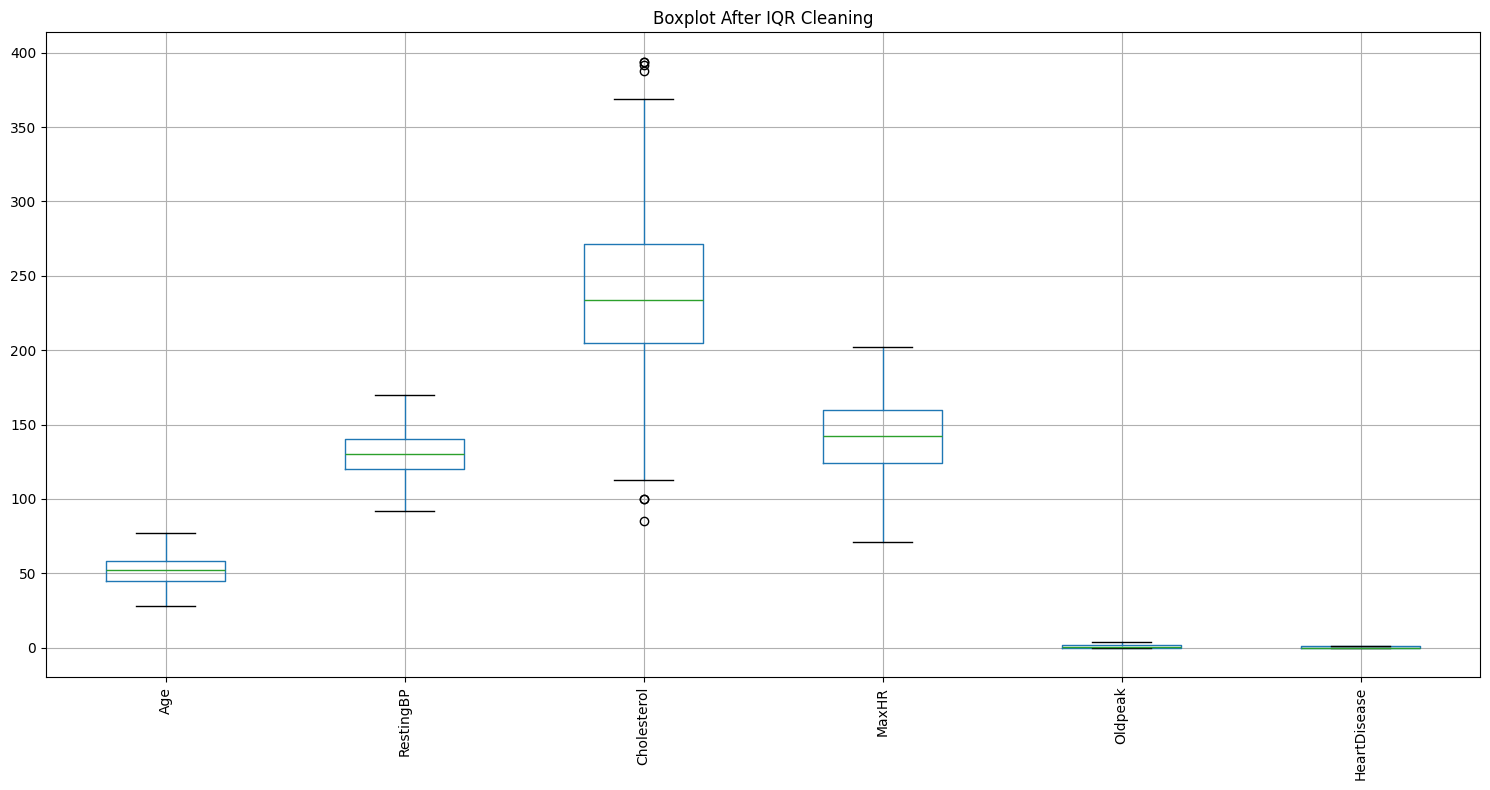

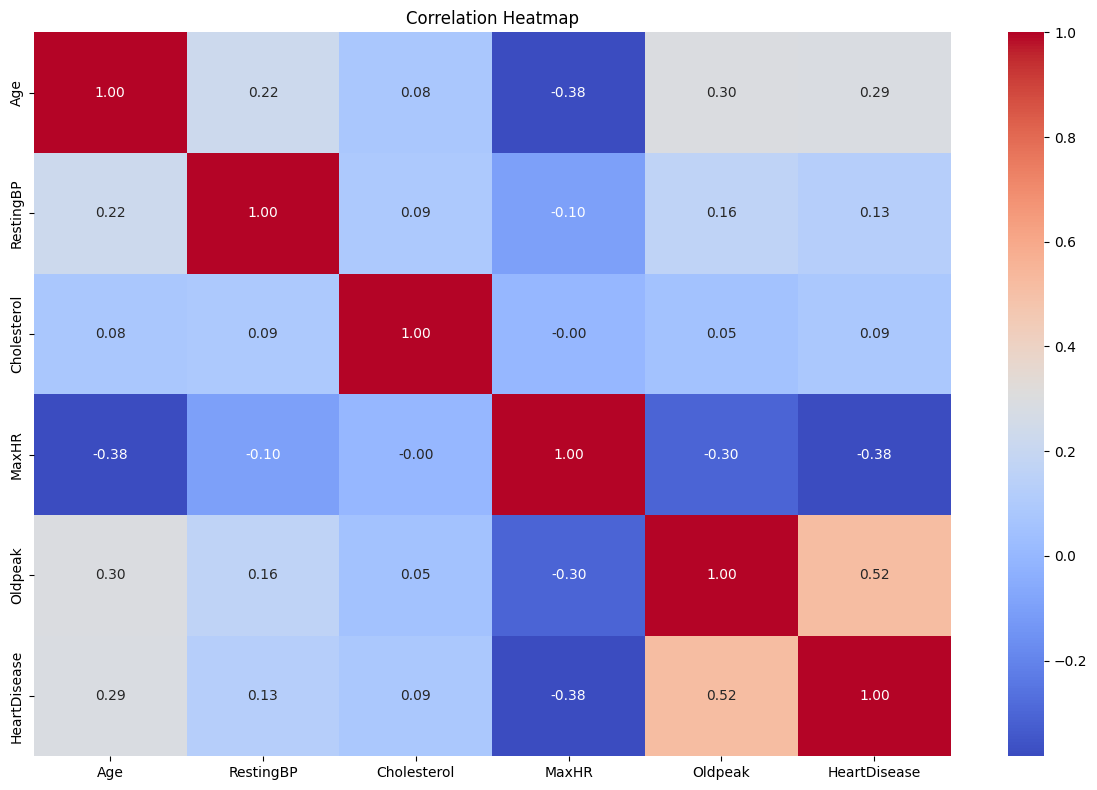


Data Cleaning Completed Successfully


In [ ]:
df.to_csv("/content/cleaned_dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully")
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:

    plt.figure(figsize=(15,8))
    df[numeric_cols].boxplot(rot=90)
    plt.title("Boxplot After IQR Cleaning")
    plt.tight_layout()
    plt.show()



if len(numeric_cols) > 1:

    plt.figure(figsize=(12,8))
    sns.heatmap(
        df[numeric_cols].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

print("\nData Cleaning Completed Successfully")

In [ ]:
df = pd.read_csv("/content/cleaned_dataset.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...
582,57,F,ASY,140,241,Normal,123,Y,0.2,Flat,1
583,45,M,TA,110,264,Normal,132,N,1.2,Flat,1
584,57,M,ASY,130,131,Normal,115,Y,1.2,Flat,1
585,57,F,ATA,130,236,LVH,174,N,0.0,Flat,1


In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
train_cols = X_train.columns
X_test = X_test.reindex(columns=train_cols, fill_value=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = SVR(kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.442179633478742
MSE: 0.13368619384382627
